# GSE134649 初步分析
结肠组织 CD8+ T Cell 样本，6个样本  
3UC，3HC
- UC17-UC19
- HC14-HC16

# 文件说明
- **文件名**: 5_GSE134649.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-23  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/5_GSE134649_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


In [2]:
!pwd

/home/future/UC_Treg_Project/notebooks/1_preprocessing


## 读取MTX类型数据

In [4]:
import os

data_dirs = ["/mnt/e/UC/scRNA-seq_RAW/5_GSE134649"]
adatas = []

for data_dir in data_dirs:
    for sample in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, sample)
        if not os.path.isdir(path):
            continue

        ad = sc.read_10x_mtx(path, var_names='gene_symbols', cache=False)
        sc.pp.filter_cells(ad, min_genes=200)
        sc.pp.filter_genes(ad, min_cells=3)

        ad.obs['GSM_id'] = sample
        ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names] 
        adatas.append(ad)     

adata = sc.concat(adatas, merge='same')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


filtered out 736158 cells that have less than 200 genes expressed
filtered out 20775 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 735351 cells that have less than 200 genes expressed
filtered out 19897 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 735147 cells that have less than 200 genes expressed
filtered out 19640 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 734845 cells that have less than 200 genes expressed
filtered out 18986 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 735561 cells th

In [5]:
adata

AnnData object with n_obs × n_vars = 11448 × 12107
    obs: 'n_genes', 'GSM_id'
    var: 'gene_ids', 'feature_types'

In [6]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM3960986_UC17    2435
GSM3960985_HC16    2133
GSM3960988_UC19    2110
GSM3960984_HC15    1929
GSM3960987_UC18    1719
GSM3960983_HC14    1122
Name: count, dtype: int64

In [7]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [8]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||||------------------------- 2795/16311 MiB (17.1%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 11,448 cells × 12,107 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 4423 (range: 224-42603)
     • Mean genes: 1559 (range: 163-6451)
     • Mean mitochondrial %: 9.7% (max: 94.5%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 214 cells failed (1.9%)
     • Genes filter (≥250): 235 cells failed (2.1%)
     • Mitochondrial filter (≤0.2): 1,021 cells failed (8.9%)
   ✓ Combined QC filters: 1,166 cells removed (10.2%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=

AnnData object with n_obs × n_vars = 10282 × 12107
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）


In [9]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "5_GSE134649.h5ad"), compression='gzip')

In [10]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 12107/12107 genes are kept.     Among 12107 genes, 12107 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKV3-20', 'MALAT1', 'IGLV2-14']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.0164682865142822 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA Ge

In [11]:
adata

AnnData object with n_obs × n_vars = 10282 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

指控后每个样本细胞数

In [12]:
adata.obs['id'].value_counts()

id
UC17    2125
UC19    1960
HC16    1930
HC15    1714
UC18    1508
HC14    1045
Name: count, dtype: int64

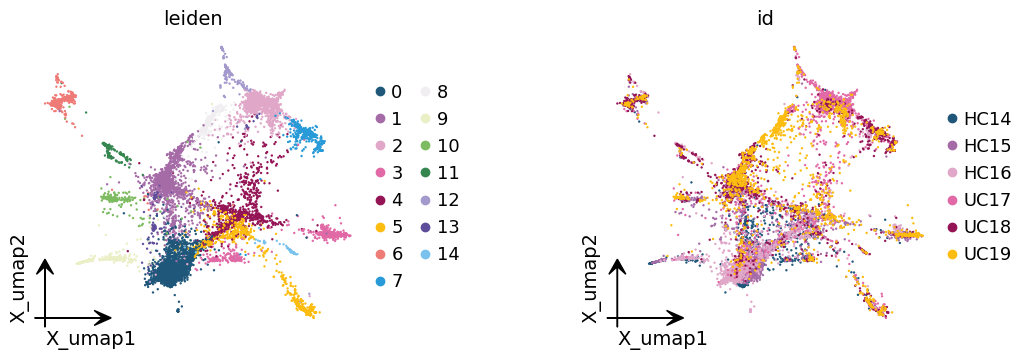

In [13]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

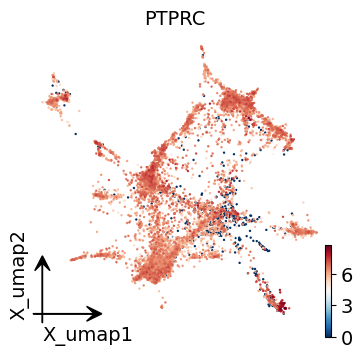

In [15]:
# 粗略查看免疫基因
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC'],
                frameon='small')

## GPT自动注释

In [16]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


{'0': ['CD8B',
  'VIM',
  'LGALS1',
  'CCL5',
  'FOS',
  'HOPX',
  'XCL2',
  'CD160',
  'ANXA1',
  'S100A10'],
 '1': ['NKG7',
  'CD74',
  'TUBA4A',
  'SH2D1A',
  'CST7',
  'GZMK',
  'CMC1',
  'ITGB2',
  'GZMH',
  'CXCR4'],
 '10': ['CD7',
  'FAM177A1',
  'IFITM2',
  'SPINT2',
  'IFITM1',
  'XCL1',
  'LEF1',
  'TCF7',
  'ZNF683',
  'ID3'],
 '11': ['PLEK',
  'ADGRG1',
  'NKG7',
  'CTSW',
  'FGFBP2',
  'CST7',
  'LITAF',
  'ITGB2',
  'EMP3',
  'GZMH'],
 '12': ['CLSPN',
  'MCM3',
  'DUT',
  'TUBA1B',
  'TYMS',
  'STMN1',
  'MCM7',
  'DEK',
  'HMGN2',
  'GINS2'],
 '13': ['TRBV7-4', 'TRBV7-7', 'TRBV7-2', 'TRBV7-9', 'TRBV7-6'],
 '14': ['HLA-DRA', 'CST3', 'HLA-DQA1', 'TYROBP', 'AIF1'],
 '2': ['GZMA',
  'ZEB2',
  'ALOX5AP',
  'ITGAE',
  'CXCR6',
  'ENTPD1',
  'DUSP4',
  'TNFRSF9',
  'KLRB1',
  'AC092580.4'],
 '3': ['TRAV1-2',
  'NFKBIA',
  'AQP3',
  'LTB',
  'NCR3',
  'IL4I1',
  'IL7R',
  'S100A4',
  'KLRB1',
  'SLC4A10'],
 '4': ['RP11-290D2.6'],
 '5': ['HSPA1B', 'JUN', 'TNF', 'FOS', 'EGR1', 'DU

In [17]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='T cells',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Cytotoxic T cells',
 '1': 'Effector memory T cells',
 '10': 'Naive T cells',
 '11': 'Cytotoxic T cells',
 '12': 'Proliferating T cells',
 '13': 'T cell receptor gamma delta T cells',
 '14': 'Antigen presenting cells',
 '2': 'Tissue-resident memory T cells',
 '3': 'Mucosal associated invariant T cells',
 '4': 'Undefined',
 '5': 'Activated T cells',
 '6': 'Central memory T cells',
 '7': 'Helper T cells',
 '8': 'Cytotoxic T cells',
 '9': 'Mixed T cell types'}

In [ ]:
#os.environ['AGI_API_KEY'] = 'sk-p0VgGvztXDK2erOoUul7cHcSDt4UduGk6f8voA0zn1F1L5xe'
#result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='moonshot-v1-8k',
                               provider='kimi',
                               topgenenumber=10)
#result

In [18]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

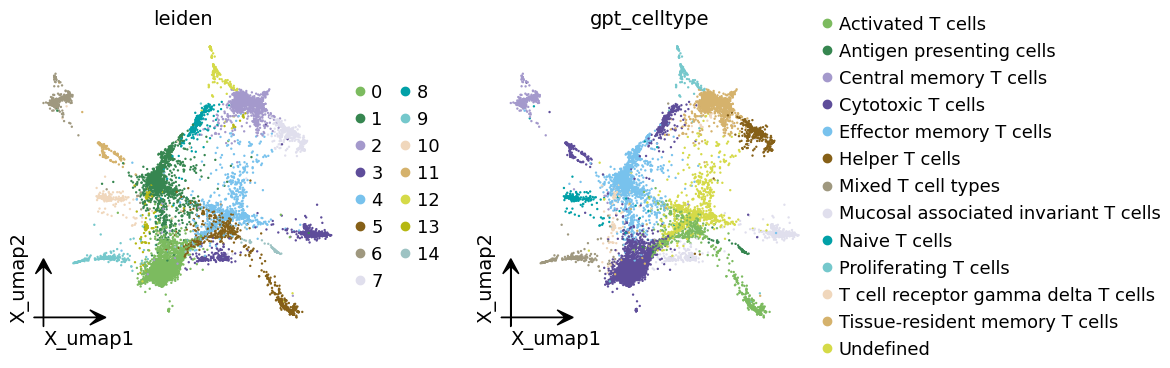

In [19]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [20]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Cytotoxic T cells                       27.864229
Effector memory T cells                 15.376386
Tissue-resident memory T cells          12.244699
Mucosal associated invariant T cells     9.054659
Undefined                                8.655904
Activated T cells                        7.722233
Central memory T cells                   5.028205
Helper T cells                           4.716981
Mixed T cell types                       3.102509
Naive T cells                            2.577320
Proliferating T cells                    1.672826
T cell receptor gamma delta T cells      1.060105
Antigen presenting cells                 0.923945
Name: proportion, dtype: float64


# 总结
优点：
- GPT对于T细胞的结果值得借鉴